<a href="https://colab.research.google.com/github/kaoru1018/diabetes-100k-analysis/blob/main/%E3%83%87%E3%83%BC%E3%82%BF%E3%82%B5%E3%82%A4%E3%82%A8%E3%83%B3%E3%82%B9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- 設定 ---
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

# 1. データの読み込み（エラー回避用）
file_name = 'diabetic_data.csv'

if os.path.exists(file_name):
#まず最初に、パソコンの中をのぞいて指定したファイルがあるかどうかをチェックします。
#osはWindowsとかMacの事

    df = pd.read_csv(file_name)
#動作: CSVファイルを読み込み、df という名前のデータフレーム（表形式のデータ）に保存します。
    print(f"✓ 読み込み成功: {df.shape[0]:,} 患者 × {df.shape[1]} 項目")
else:
    print(f"❌ エラー: '{file_name}' が見つかりません。")
    print("Kaggleからダウンロードしたファイルを、このプログラムと同じフォルダに置いてくださいね。")
    # ここで停止させないためのダミー
    df = pd.DataFrame()

# --- 2. 下準備（クレンジング） ---
if not df.empty:
    # 表（df）が空っぽでなければ、以下の処理を進める
    df_clean = df.copy()
    # 原本を汚さないようにコピーを作る

    # 数値データ：中央値で埋める
    num_cols = df_clean.select_dtypes(include=[np.number]).columns
    # データの中から「数字（整数や小数）」の列だけをリストアップする
    #つまり、「計算ができる『数値型』として認識されている列を、すべて自動でリストアップする」ということ
    for col in num_cols:
    # リストアップした列を一つずつ処理する
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())
    # その列の空っぽ（NaN）の場所に、その列の「中央値（median）」を入れて埋める

    # カテゴリ（文字）データ：最頻値（一番多い値）で埋める
    cat_cols = df_clean.select_dtypes(include=['object', 'string']).columns
    for col in cat_cols:
        if df_clean[col].isnull().sum() > 0:
    #もしその列の中に、一つでも空っぽ（isnull）のデータが含まれていたら（sumが0より大きければ）
            df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])
    #その列で「一番よく登場する言葉（最頻値：mode）」の1番目[0]を使って、空っぽの場所を埋めます。
    #Pandasのルールでは、同率1位が複数ある場合、「辞書順（あいうえお順やアルファベット順）」や「データの中に先に登場した順」で名簿の並びが決まります。

    # 3. 特殊な文字 "?" を数値に変換する
    # このデータセットは欠損値が "?" で入っていることが多いので、数値変換を試みます
    numeric_cols_to_convert = [
        'time_in_hospital', 'num_procedures', 'num_lab_procedures',
        'num_medications', 'number_outpatient', 'number_emergency',
        'number_inpatient'
    ]
    for col in numeric_cols_to_convert:
        if col in df_clean.columns:
            # errors='coerce' は「数字にできない文字は強制的に欠損値(NaN)にする」という意味
            df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
            # 変換後に発生した欠損値を再度埋める
            df_clean[col] = df_clean[col].fillna(df_clean[col].median())

    # 4. 「30日以内の再入院」を予測ターゲットにする（二値化）
    # 元の readmitted は '<30', '>30', 'NO' の3種類。これを 1 or 0 に変える
    df_clean['readmitted_30d'] = (df_clean['readmitted'] == '<30').astype(int)

    # 5. 結果の表示
    print("✓ データ準備完了。統計分析を開始します。\n")
    print("--- 数値データの基本統計量（四分位を含む） ---")

    # describe() で平均、標準偏差、最小、四分位、最大を一気に計算
    stats = df_clean.describe()
    display(stats)

    # 6. 補足：特に重要な項目の「四分位」をピックアップして解説
    print("\n【分析ポイント】")
    hospital_stay = stats['time_in_hospital']
    print(f"・入院日数の中央値（50%）は {hospital_stay['50%']:.0f} 日です。")
    print(f"・入院日数の上位25%（75%タイル）は {hospital_stay['75%']:.0f} 日以上の人たちです。")

else:
    print(f"❌ エラー: '{file_name}' が見つかりません。")

✓ 読み込み成功: 94,564 患者 × 50 項目
✓ データ準備完了。統計分析を開始します。

--- 数値データの基本統計量（四分位を含む） ---


,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,readmitted_30d
count,9.456400e+04,9.456400e+04,94564.000000,94564.000000,94564.000000,94564.000000,94564.000000,94564.000000,94564.000000,94564.000000,94564.000000,94564.000000,94564.000000,94564.000000
mean,1.475339e+08,5.152131e+07,2.050865,3.773074,5.776723,4.413794,43.163519,1.338776,15.951282,0.359386,0.191711,0.632757,7.361195,0.111850
std,8.289753e+07,3.669269e+07,1.464545,5.360602,4.131408,2.996457,19.525523,1.697379,8.131104,1.241147,0.925143,1.256454,1.943991,0.315184
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,8.076686e+07,2.321308e+07,1.000000,1.000000,1.000000,2.000000,32.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000,0.000000
50%,1.454069e+08,4.375550e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000,0.000000
75%,2.044408e+08,8.585396e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000,0.000000
max,3.496593e+08,1.894451e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000,1.000000



【分析ポイント】
・入院日数の中央値（50%）は 4 日です。
・入院日数の上位25%（75%タイル）は 6 日以上の人たちです。


✓ 読み込み成功: 101,766 患者 × 50 項目

--- 箱ひげ図を表示します ---


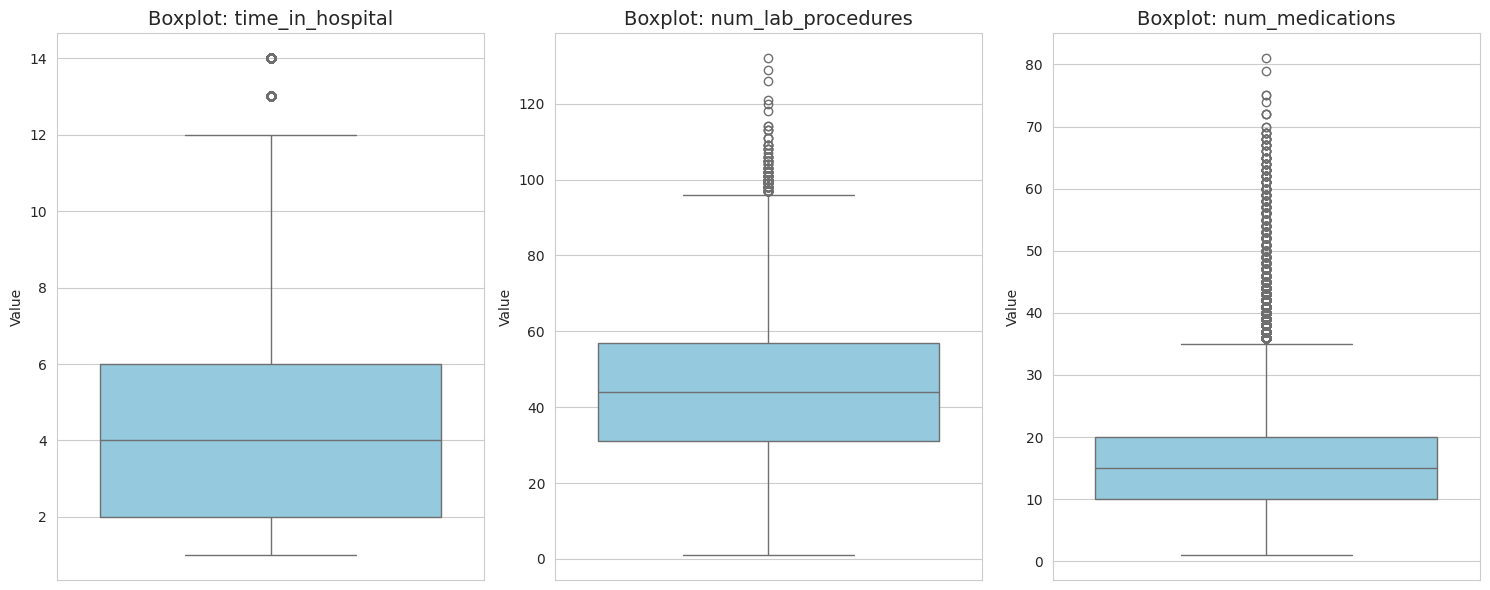

In [4]:
#「入院日数」「検査数」「薬の数」の3つの重要な項目を比較する箱ひげ図

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- 設定 ---
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

# 1. データの読み込み（エラー回避用）
file_name = 'diabetic_data.csv'

if os.path.exists(file_name):
#まず最初に、パソコンの中をのぞいて指定したファイルがあるかどうかをチェックします。
#osはWindowsとかMacの事

    df = pd.read_csv(file_name)
#動作: CSVファイルを読み込み、df という名前のデータフレーム（表形式のデータ）に保存します。
    print(f"✓ 読み込み成功: {df.shape[0]:,} 患者 × {df.shape[1]} 項目")
else:
    print(f"❌ エラー: '{file_name}' が見つかりません。")
    print("Kaggleからダウンロードしたファイルを、このプログラムと同じフォルダに置いてくださいね。")
    # ここで停止させないためのダミー
    df = pd.DataFrame()

# --- 2. 下準備（クレンジング） ---
if not df.empty:
    # 表（df）が空っぽでなければ、以下の処理を進める
    df_clean = df.copy()
    # 原本を汚さないようにコピーを作る

    # 数値データ：中央値で埋める
    num_cols = df_clean.select_dtypes(include=[np.number]).columns
    # データの中から「数字（整数や小数）」の列だけをリストアップする
    #つまり、「計算ができる『数値型』として認識されている列を、すべて自動でリストアップする」ということ
    for col in num_cols:
    # リストアップした列を一つずつ処理する
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())
    # その列の空っぽ（NaN）の場所に、その列の「中央値（median）」を入れて埋める

    # カテゴリ（文字）データ：最頻値（一番多い値）で埋める
    cat_cols = df_clean.select_dtypes(include=['object', 'string']).columns
    for col in cat_cols:
        if df_clean[col].isnull().sum() > 0:
    #もしその列の中に、一つでも空っぽ（isnull）のデータが含まれていたら（sumが0より大きければ）
            df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])
    #その列で「一番よく登場する言葉（最頻値：mode）」の1番目[0]を使って、空っぽの場所を埋めます。
    #Pandasのルールでは、同率1位が複数ある場合、「辞書順（あいうえお順やアルファベット順）」や「データの中に先に登場した順」で名簿の並びが決まります。

    # 3. 特殊な文字 "?" を数値に変換する
    # このデータセットは欠損値が "?" で入っていることが多いので、数値変換を試みます
    numeric_cols_to_convert = [
        'time_in_hospital', 'num_procedures', 'num_lab_procedures',
        'num_medications', 'number_outpatient', 'number_emergency',
        'number_inpatient'
    ]
    for col in numeric_cols_to_convert:
        if col in df_clean.columns:
            # errors='coerce' は「数字にできない文字は強制的に欠損値(NaN)にする」という意味
            df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
            # 変換後に発生した欠損値を再度埋める
            df_clean[col] = df_clean[col].fillna(df_clean[col].median())

    # 4. 「30日以内の再入院」を予測ターゲットにする（二値化）
    # 元の readmitted は '<30', '>30', 'NO' の3種類。これを 1 or 0 に変える
    df_clean['readmitted_30d'] = (df_clean['readmitted'] == '<30').astype(int)


#  5. 箱ひげ図（Boxplot）の作成
print("\n--- 箱ひげ図を表示します ---")

# グラフの土台（サイズ）を決める
plt.figure(figsize=(15, 6))

# 調べたい3つの項目をリストにする
plot_cols = ['time_in_hospital', 'num_lab_procedures', 'num_medications']

# 3つのグラフを横に並べて表示するためのループ
for i, col in enumerate(plot_cols, 1):
    plt.subplot(1, 3, i) # 1行3列のi番目にグラフを作る
    sns.boxplot(y=df_clean[col], color='skyblue') # 箱ひげ図を描く
    plt.title(f'Boxplot: {col}', fontsize=14) # グラフのタイトル
    plt.ylabel('Value') # 縦軸のラベル

# グラフ同士が重ならないように調整
plt.tight_layout()
plt.show()